# ENEM 2025: participação e distribuição das notas

Uma primeira leitura dos registros divulgados. **4.810.772 registros** compõem a base. Primeiro observamos quem participou; depois, onde se concentram as notas.

Este notebook reúne a apresentação. Para reexecutar, mantenha-o dentro do projeto e use o ambiente `.venv`. Uma cópia fora do projeto serve para leitura das saídas já preservadas; depende do projeto para executar. Não há processamento do raw aqui.

In [1]:
from pathlib import Path
import sys
raiz = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/desempenho.py").is_file())
if str(raiz) not in sys.path:
    sys.path.insert(0, str(raiz))
from src.desempenho_execucao import executar_desempenho
from src.desempenho_graficos import gerar_graficos
import pandas as pd
from IPython.display import display, Image
resultados, auditoria = executar_desempenho(raiz)
arquivos = gerar_graficos(resultados, raiz / "apresentacao/graficos")
tabela = pd.DataFrame(resultados)

## A presença muda entre as áreas

Linguagens e Humanas registram **71,87% de presença**; Natureza e Matemática, **67,77%**. O denominador é o mesmo: todos os registros da base. A análise das trajetórias entre os dois dias será um próximo passo; estes totais, sozinhos, não dizem quem deixou de comparecer.

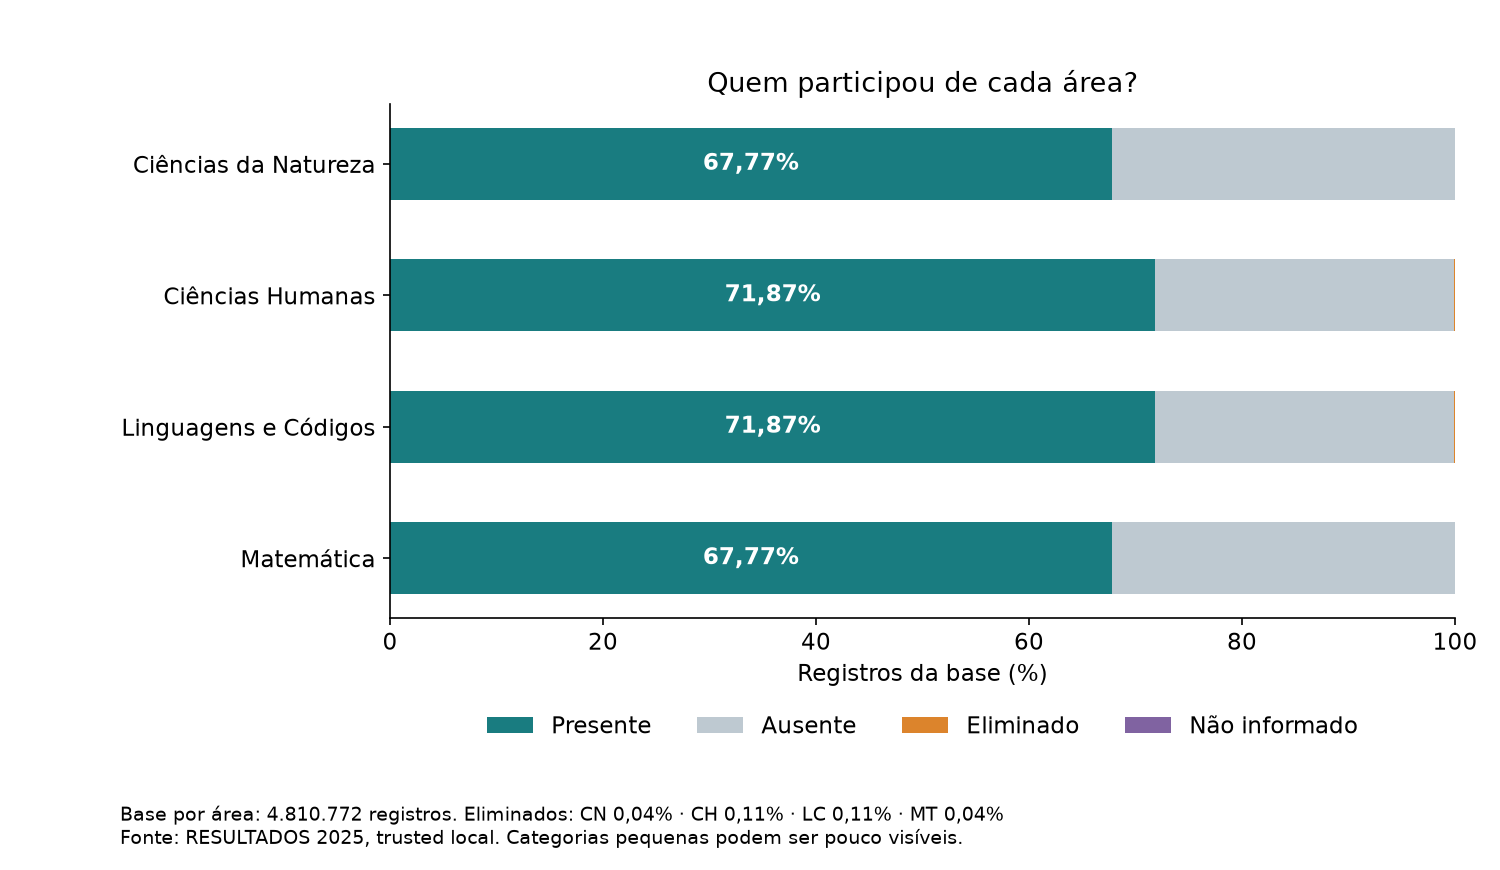

In [2]:
display(Image(filename=str(arquivos[0])))

## Para olhar notas, olhamos quem participou

Cada área inclui somente presentes com nota disponível naquela área. **Zero é mantido.** Não exigimos participação em todas as áreas. São 3.260.336 notas em Natureza e Matemática e 3.457.555 em Humanas e Linguagens, por área. Todos os presentes possuem nota neste recorte.

No gráfico seguinte, a linha fina vai da menor à maior nota encontrada. A faixa colorida reúne os 50% centrais; o ponto marca a mediana — metade das notas fica de cada lado.

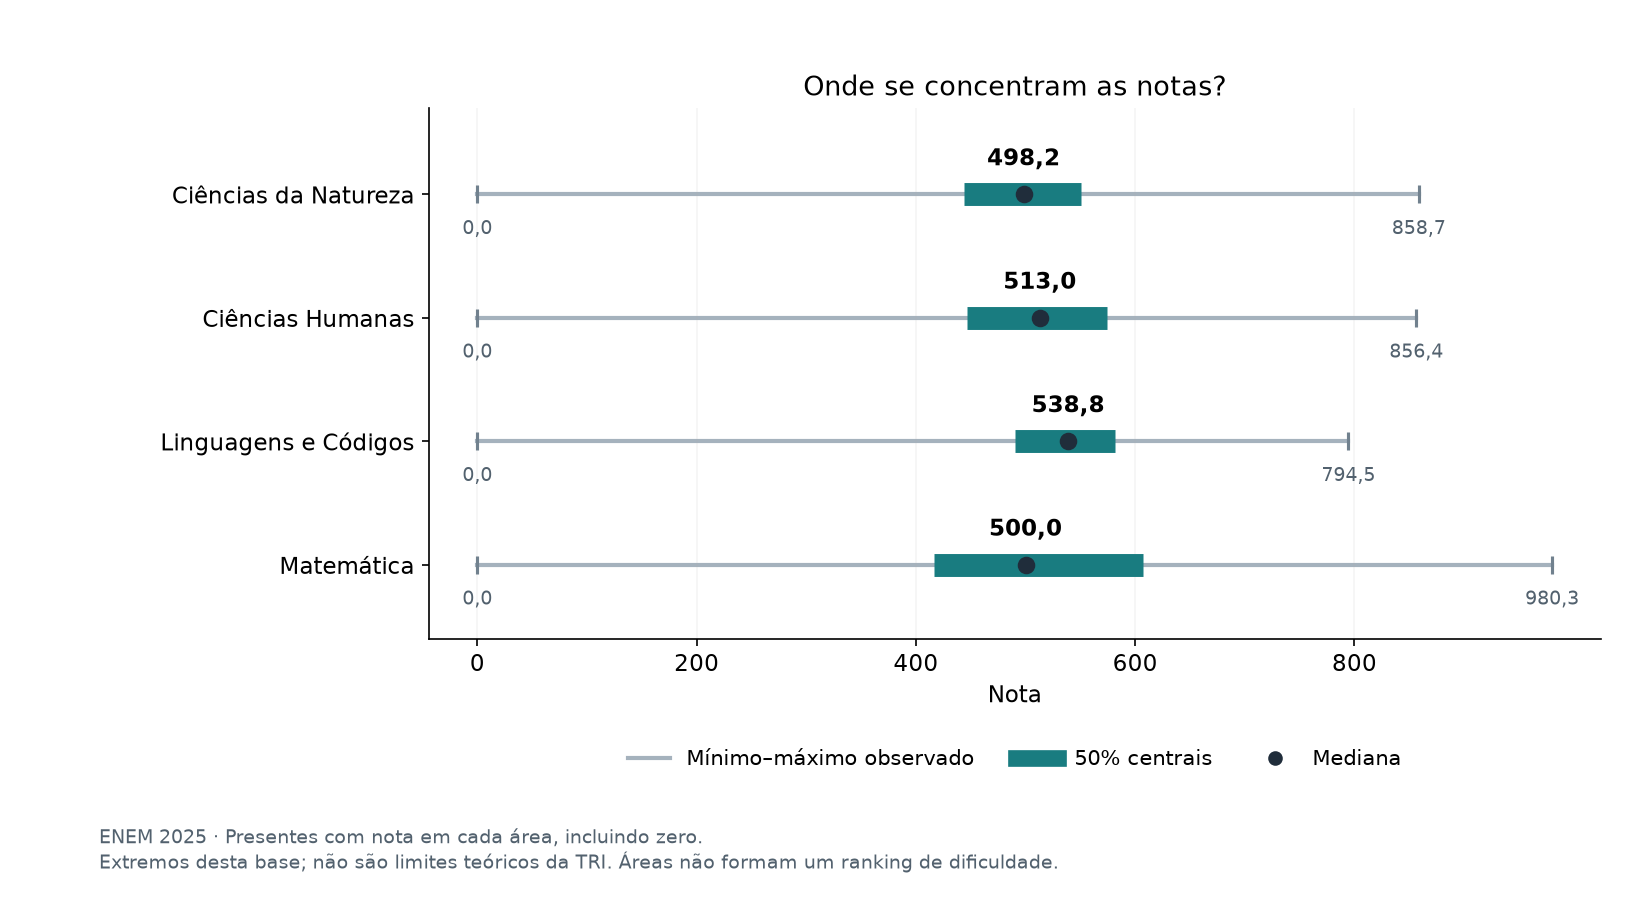

In [3]:
display(Image(filename=str(arquivos[1])))

## Os extremos e o centro contam partes diferentes da história

As medianas vão de 498,2 em Natureza a 538,8 em Linguagens. Em Matemática, os 50% centrais vão de 416,5 a 606,8; a média é 519,98 e a mediana, 500,0. São descrições desta população, não um ranking de dificuldade. A tabela permite conferir os números sem sobrecarregar o gráfico.

In [4]:
colunas = {"nome_area":"Área", "elegiveis":"Notas analisadas", "minimo_observado":"Mínimo observado", "q1":"Q1", "mediana":"Mediana", "q3":"Q3", "maximo_observado":"Máximo observado", "media":"Média"}
display(tabela[list(colunas)].rename(columns=colunas).round(2))

,Área,Notas analisadas,Mínimo observado,Q1,Mediana,Q3,Máximo observado,Média
0,Ciências da Natureza,3260336,0.0,443.5,498.2,550.9,858.7,499.97
1,Ciências Humanas,3457555,0.0,446.6,513.0,574.0,856.4,511.19
2,Linguagens e Códigos,3457555,0.0,490.3,538.8,581.6,794.5,532.12
3,Matemática,3260336,0.0,416.5,500.0,606.8,980.3,519.98


## Observado não significa limite teórico

Há notas zero nesta base e elas foram preservadas. Os máximos observados são 858,7 em Natureza, 856,4 em Humanas, 794,5 em Linguagens e 980,3 em Matemática. Isso não estabelece os limites possíveis das provas nem explica a origem de cada zero.

A TRI não tem uma escala universal fixa de 0 a 1000; os limites de uma prova dependem dos itens. Não estimamos esses limites neste trabalho. [Referência: guia do Inep](https://www.gov.br/inep/pt-br/centrais-de-conteudo/acervo-linha-editorial/publicacoes-institucionais/avaliacoes-e-exames-da-educacao-basica/entenda-a-sua-nota-no-enem-guia-do-participante).

## O que investigar depois?

1. Participação entre os dois dias, com regras explícitas para eliminações e divergências.
2. Presença e notas por região de aplicação, ampliando a trusted; distinguir taxas de volumes antes de selecionar três regiões com mais/menos presença. Local de prova não é residência.
3. Perfil de renda familiar em PARTICIPANTES, separado das notas: não há chave individual comum com RESULTADOS em 2025.

Nenhuma dessas análises adicionais foi executada nesta entrega. Contratos e trilha de validação estão em `docs/` e `reports/`.